In [30]:
import jax.numpy as jnp
from jax.scipy.linalg import solve, lu
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator 
import numpy as np  
#from lemkelcp import lemkelcp as lcp

# 4.6 Computation of American Options

In [31]:
# ---- Parameters ----
#grid var
v_max = 150
m = 150
x_max = 3
x_min = -5

#option, expiration time, strike price
option_type = "call"  # "put" or "call"
T = 1
K = 40

#constant interest rate, dividend rate, volatility
r = 0.06
delta = 0.0
sigma = 0.4

#theta for implicity percentage of theta-method
theta = 0.5


In [32]:
# ---- Grid setup ----
delta_x = (x_max - x_min) / m
x = jnp.linspace(x_min, x_max, m + 1)
x_interior = x[1:-1]  

tau_max = 0.5 * sigma**2 * T
delta_tau = tau_max / v_max
tau = jnp.linspace(0, tau_max, v_max + 1)

lamb = delta_tau / (delta_x ** 2)
alpha = lamb * theta

In [33]:
# ---- matrice g(x,tau) as in Problem 4.7 ----
# dim(m+1, v_max+1)
q = 2 * r / sigma**2
q_delta = 2 * (r - delta) / (sigma ** 2)

init = jnp.exp(0.5*x[:, None] * (q_delta-1)) - jnp.exp(0.5*x[:, None] * (q_delta+1))
factor = jnp.exp(0.25*tau * ((q_delta - 1)**2 + 4*q))

if option_type=="put":
    g = factor[None,:] * jnp.maximum(init, 0)
else:
    g = factor[None,:] * jnp.maximum(-init, 0)

g_interior = g[1:-1, :]

In [34]:
# ---- Initial condition w ----
w = jnp.zeros((m+1, v_max+1))
w = w.at[0].set(g[0])
w = w.at[-1].set(g[-1])
w = w.at[:,0].set(g[:,0])
#w_interior = w[1:-1, :]

In [35]:
# ---- lemkelcp solver code from https://github.com/AndyLamperski/lemkelcp.git ----
class lemketableau:
    def __init__(self,M,q,maxIter = 100):
        n = len(q)
        self.T = np.hstack((np.eye(n),-M,-np.ones((n,1)),q.reshape((n,1))))
        self.n = n
        self.wPos = np.arange(n)
        self.zPos = np.arange(n,2*n)
        self.W = 0
        self.Z = 1
        self.Y = 2
        self.Q = 3
        TbInd = np.vstack((self.W*np.ones(n,dtype=int),
                           np.arange(n,dtype=int)))
        TnbInd = np.vstack((self.Z*np.ones(n,dtype=int),
                            np.arange(n,dtype=int)))
        DriveInd = np.array([[self.Y],[0]])
        QInd = np.array([[self.Q],[0]])
        self.Tind = np.hstack((TbInd,TnbInd,DriveInd,QInd))
        self.maxIter = maxIter
        
        
    def lemkeAlgorithm(self):
        initVal = self.initialize()
        if not initVal:
            return np.zeros(self.n),0,'Solution Found'
        
        for k in range(self.maxIter):
            stepVal = self.step()
            if self.Tind[0,-2] == self.Y:
                # Solution Found
                z = self.extractSolution()
                return z,0,'Solution Found'
            elif not stepVal:
                return None,1,'Secondary ray found'
            
        return None,2,'Max Iterations Exceeded'
        
    def initialize(self):
        q = self.T[:,-1]
        minQ = np.min(q)
        if minQ < 0:
            ind = np.argmin(q)
            self.clearDriverColumn(ind)
            self.pivot(ind)
            
            return True
        else:
            return False
            
    def step(self):
        q = self.T[:,-1]
        a = self.T[:,-2]
        ind = np.nan
        minRatio = np.inf
        for i in range(self.n):
            if a[i] > 0:
                newRatio = q[i] / a[i]
                if newRatio < minRatio:
                    ind = i
                    minRatio = newRatio
                    
        if minRatio < np.inf:
            self.clearDriverColumn(ind)
            self.pivot(ind)
            return True
        else:
            return False
        
    def extractSolution(self):
        z = np.zeros(self.n)
        q = self.T[:,-1]
        for i in range(self.n):
            if self.Tind[0,i] == self.Z:
                z[self.Tind[1,i]] = q[i]
        return z
    def partnerPos(self,pos):
        v,ind = self.Tind[:,pos]
        if v == self.W:
            ppos = self.zPos[ind]
        elif v == self.Z:
            ppos = self.wPos[ind]
        else:
            ppos = None
        return ppos
        
    def pivot(self,pos):
        ppos = self.partnerPos(pos)
        if ppos is not None:
            self.swapColumns(pos,ppos)
            self.swapColumns(pos,-2)
            return True
        else:
            self.swapColumns(pos,-2)
            return False
            
        
    
    def swapMatColumns(self,M,i,j):
        Mi = np.array(M[:,i],copy=True)
        Mj = np.array(M[:,j],copy=True)
        M[:,i] = Mj
        M[:,j] = Mi
        return M
    
    def swapPos(self,v,ind,newPos):
        if v == self.W:
            self.wPos[ind] = newPos % (2*self.n+2)
        elif v == self.Z:
            self.zPos[ind] = newPos % (2*self.n+2)
            
    
    def swapColumns(self,i,j):
        iInd = self.Tind[:,i]
        jInd = self.Tind[:,j]
        
        v,ind = iInd
        self.swapPos(v,ind,j)
        v,ind = jInd
        self.swapPos(v,ind,i)
        
        self.Tind = self.swapMatColumns(self.Tind,i,j)
        self.T = self.swapMatColumns(self.T,i,j)
     
    
    def clearDriverColumn(self,ind):
        a = self.T[ind,-2]
        self.T[ind] /= a
        for i in range(self.n):
            if i != ind:
                b = self.T[i,-2]
                self.T[i] -= b * self.T[ind]
                
        
    def ind2str(self,indvec):
        v,pos = indvec
        if v == self.W:
            s = 'w%d' % pos
        elif v == self.Z:
            s = 'z%d' % pos
        elif v == self.Y:
            s = 'y'
        else:
            s = 'q'
        return s
    
    def indexStringArray(self):
        indstr = np.array([self.ind2str(indvec) for indvec in self.Tind.T],dtype=object)
        return indstr
        
    def indexedTableau(self):
        indstr = self.indexStringArray()
        return np.vstack((indstr,self.T))
    def __repr__(self):
        IT = self.indexedTableau()
        return IT.__repr__()
    def __str__(self):
        IT = self.indexedTableau()
        return IT.__str__()
    
def lemkelcp(M,q,maxIter=100):
    """
    sol = lemkelcp(M,q,maxIter)

    Uses Lemke's algorithm to copute a solution to the 
    linear complementarity problem:

    Mz + q >= 0
    z >= 0 
    z'(Mz+q) = 0

    The inputs are given by:

    M - an nxn numpy array
    q - a length n numpy array 
    maxIter - an optional number of pivot iterations. Set to 100 by default

    The solution is a tuple of the form:

    z,exit_code,exit_string = sol

    The entries are summaries in the table below:
    
    |z                | exit_code | exit_string               | 
    -----------------------------------------------------------
    | solution to LCP |    0      | 'Solution Found'          |
    | None            |    1      | 'Secondary ray found'     |
    | None            |    2      | 'Max Iterations Exceeded' |    
    """

    tableau = lemketableau(M,q,maxIter)
    return tableau.lemkeAlgorithm()

In [36]:
# ---- loop - Algorithm 4.14 ----
# matrix A 4.42
diag_mainA = (1 + 2*alpha) * jnp.ones(m - 1)
diag_offA = alpha * jnp.ones(m - 2)

A = jnp.diag(diag_mainA) - jnp.diag(diag_offA, 1) - jnp.diag(diag_offA, -1)

# calc vector b
def calc_b(nu):
    b1 = jnp.array([w[1, nu] + lamb*(1-theta)*(w[2, nu] - 2*w[1, nu] + g[0, nu]) + alpha*g[0, nu+1]])
    b_i = w[2:-2, nu] + lamb*(1-theta)*(w[3:-1, nu] - 2*w[2:-2, nu] + w[1:-3, nu])
    bm_1 = jnp.array([w[-2, nu] + lamb*(1-theta)*(g[-1, nu] - 2*w[-1, nu] + w[-3, nu]) + alpha*g[-1, nu+1]])
    return jnp.concatenate([b1, b_i, bm_1])

for t_nu in range(0, v_max):
    b = calc_b(t_nu)
    q = A@g_interior[:, t_nu] - b
    z = lemkelcp(A, q, maxIter = 1000)
    w_nu = z[0] + g_interior[:, t_nu]
    w = w.at[1:-1, t_nu+1].set(w_nu)

In [37]:
# ---- Undo transformation to pass from w(x,tau) to v(x, tau) - equation (4.3)----
q = 2 * r / sigma**2

factor = jnp.exp(
    -0.5 * (q_delta - 1) * x_interior[:, None] -
    (0.25 * (q_delta - 1)**2 + q) * tau[None, :]
)
v = K * factor * w[1:-1,:]

In [38]:
# ---- Interpolation and change of variables from v(x, tau) to V(S, t) ----
v_np = np.array(v)
x_np = np.array(x_interior)
tau_np = np.array(tau)
v_interp = RegularGridInterpolator((x_np, tau_np), v_np, bounds_error=False, fill_value=None)

def V(S, t):
    x_val = np.log(S/K)
    tau_val = 0.5 * sigma**2 * (T - t)
    return v_interp([x_val, tau_val])

In [39]:
V(120, 0)

array([82.38521783])

# Visualization

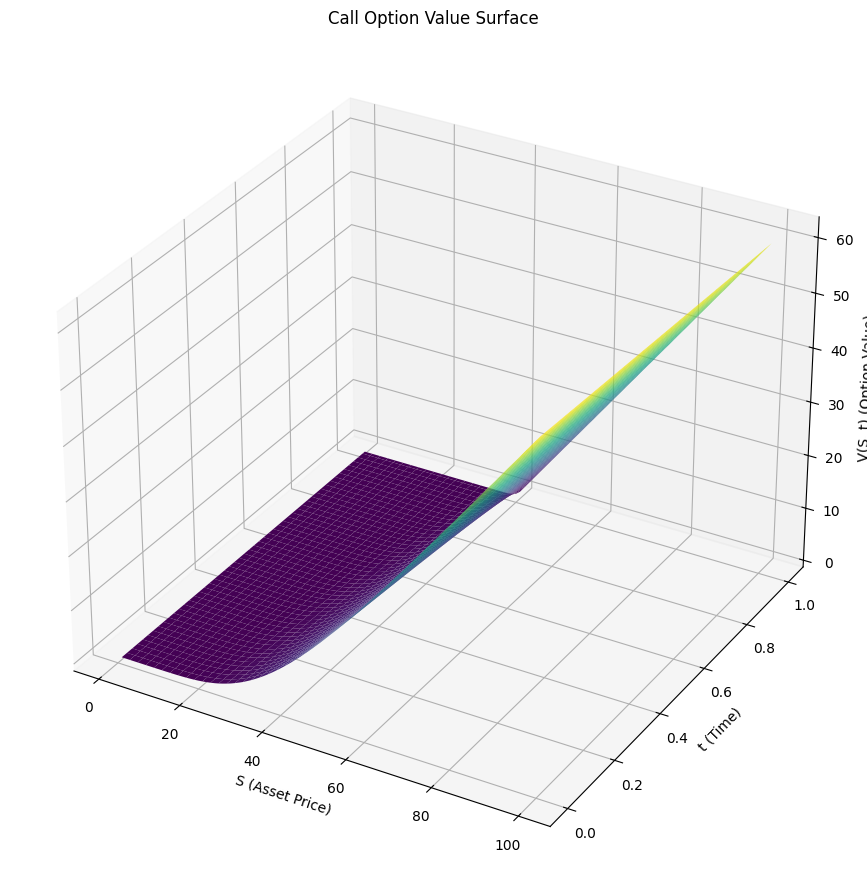

In [40]:
S_vals = np.linspace(1, 100, 100)
t_vals = np.linspace(0, T, 100)
S_grid, t_grid = np.meshgrid(S_vals, t_vals)
V_func = np.vectorize(V)
V_grid = V_func(S_grid, t_grid)

fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S_grid, t_grid, V_grid, cmap='viridis')
ax.set_xlabel('S (Asset Price)')
ax.set_ylabel('t (Time)')
ax.set_zlabel('V(S, t) (Option Value)')
ax.set_title(f"{option_type.capitalize()} Option Value Surface")
plt.tight_layout()
plt.show()

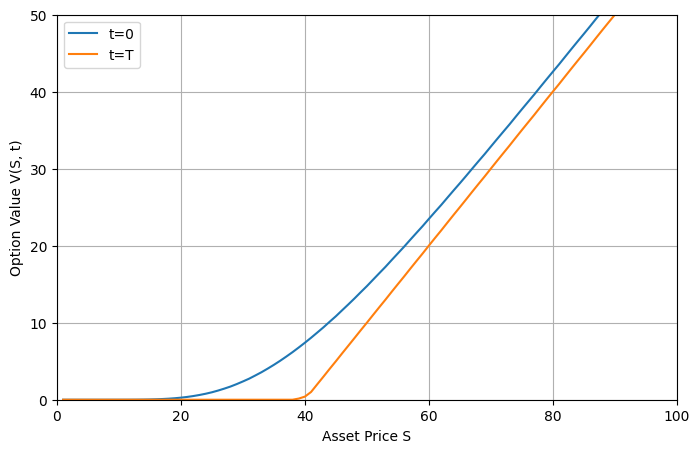

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(S_vals, [V(S,0) for S in S_vals], label="t=0")
plt.plot(S_vals, [V(S,T) for S in S_vals], label="t=T")
plt.xlabel("Asset Price S")
plt.ylabel("Option Value V(S, t)")
plt.xlim(0,100)
plt.ylim(0,50)
plt.legend()
plt.grid(True)
plt.show()